#### Neighbor AI-execution regression: controlling for E1/E2 AI exposure of the focal task and its neighbors
#### By: Peyman Shahidi (robustness build)
#### Created: 2026-07-24

**Headline being tested.** In the local-context logit (Prediction 3, Table `tab:DWA_regression_aiExecution_mainSample`),
the probability that a *focal* task is executed by AI rises when its **neighbors** at positions t-2, t-1, t+1, t+2 are
themselves AI-executed. The paper's specification controls for the focal task's AI-exposure status coded as E1-only,
plus the occupation's task count. A natural concern is that AI exposure clusters along the workflow, so the
neighbor-execution flags could partly proxy for the neighbors' *exposure* rather than a chaining / local-context effect.

**What this notebook adds.** Same samples and six specifications as `onet_antrhopicIndex_execTypeVaryingDWA.ipynb`,
estimated under three control sets:
1. `baseline`: the paper's controls (focal `is_exposed`, E1-only human label, plus `num_tasks`). Replication anchor.
2. `e12_focal`: focal exposure recoded so that **E1 and E2 both count as AI-exposed** (`human_labels` in {E1, E2}),
   matching the exposure definition used in the fragmentation analysis (Definition 1).
3. `e12_focal_nbrs`: additionally controls for the **E1/E2 exposure of the four neighbors** (t-2, t-1, t+1, t+2).
   This is the requested robustness.

Tasks with missing exposure labels are coded unexposed, as in the baseline. **Inference:** analytic **DWA-clustered**
covariance on the logit coefficients; AMEs are the discrete-change effects (point estimates identical to the paper's)
with **delta-method** standard errors computed from the clustered covariance, replacing the paper's B=200 cluster
bootstrap (instant, no simulation noise). No placebo reshuffle here, only the observed regressions.

**Outputs** are written to new subfolders so they stay separate from the main-analysis outputs:
- data: `data/computed_objects/execTypeVaryingDWA_anthropicIndex_E1E2exposureControls/` (CSVs and `tables/*.tex`)
- plots: `writeup/plots/execTypeVaryingDWA_E1E2exposureControls/`

In [1]:
import os, glob
import numpy as np, pandas as pd
import patsy
import statsmodels.formula.api as smf
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 220)

In [2]:
# ====================== PARAMETERS ======================
dependent_var = 'is_ai'                    # focal task executed by AI (Augmentation|Automation)
TARGET_REGS   = ['prev2_is_ai', 'prev_is_ai', 'next_is_ai', 'next2_is_ai']
EXPO_FOCAL    = 'is_exposed_e12'           # E1 or E2 (human labels), focal task
EXPO_NBR_REGS = ['prev2_is_exposed_e12', 'prev_is_exposed_e12', 'next_is_exposed_e12', 'next2_is_exposed_e12']

VAR_LABELS = {'prev2_is_ai': '(t-2) Task AI', 'prev_is_ai': '(t-1) Task AI',
              'next_is_ai': '(t+1) Task AI', 'next2_is_ai': '(t+2) Task AI',
              'is_exposed': 'Focal Task AI-Exposed (E1)',
              'is_exposed_e12': 'Focal Task AI-Exposed (E1/E2)',
              'prev2_is_exposed_e12': '(t-2) Task AI-Exposed (E1/E2)',
              'prev_is_exposed_e12': '(t-1) Task AI-Exposed (E1/E2)',
              'next_is_exposed_e12': '(t+1) Task AI-Exposed (E1/E2)',
              'next2_is_exposed_e12': '(t+2) Task AI-Exposed (E1/E2)'}

# Control variants: the paper's baseline vs the two E1/E2 exposure-control builds
VARIANTS = {
    'baseline':       ['is_exposed'],              # paper controls (E1-only, focal task)
    'e12_focal':      [EXPO_FOCAL],                # focal exposure recoded to E1|E2
    'e12_focal_nbrs': [EXPO_FOCAL] + EXPO_NBR_REGS # + neighbors' E1|E2 exposure (requested robustness)
}
VARIANT_LABEL = {'baseline': 'paper controls (E1 focal)', 'e12_focal': 'E1/E2 focal',
                 'e12_focal_nbrs': 'E1/E2 focal + neighbors'}

SPEC_ORDER = ['no_fe_no_dwa', 'major_fe_no_dwa', 'minor_fe_no_dwa', 'no_fe_with_dwa',
              'no_fe_no_dwa_withTaskDWACount', 'no_fe_with_dwa_withTaskDWACount']
star = lambda p: "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

In [3]:
main_folder_path = ".."
input_data_path = f"{main_folder_path}/data"
merged_file = f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"
baseline_results_path = f"{input_data_path}/computed_objects/execTypeVaryingDWA_anthropicIndex_noTasksWithRepetitiveDWAs/regression_summaries_is_ai"

# new subfolders: keep every output of this robustness separate from the main-analysis outputs
output_data_path  = f"{input_data_path}/computed_objects/execTypeVaryingDWA_anthropicIndex_E1E2exposureControls"
output_table_path = f"{output_data_path}/tables"
output_plot_path  = f"{main_folder_path}/writeup/plots/execTypeVaryingDWA_E1E2exposureControls"
for p in [output_data_path, output_table_path, output_plot_path]: os.makedirs(p, exist_ok=True)

## Load the DWA helper objects (identical to the baseline `onet_antrhopicIndex_execTypeVaryingDWA.ipynb`)

In [4]:
# Tasks that survived the DWA task-similarity procedure (DWAs with >1 task)
dwa_csv_files = glob.glob(os.path.join(f"{input_data_path}/computed_objects/similar_dwa_tasks/similarTasks", "*.csv"))
dwa_dfs = [pd.read_csv(f) for f in dwa_csv_files]
df_all = pd.concat([d for d in dwa_dfs if len(d) > 1], ignore_index=True)
repetitive_dwa_task_ids = df_all['Task ID'].unique().tolist()

dwa_task_mapping = pd.read_csv(f"{input_data_path}/computed_objects/similar_dwa_tasks/dwa_task_mapping.csv")
dwa_task_counts = dwa_task_mapping.groupby('Task ID')['DWA ID'].nunique().reset_index(name='n')
unique_task_dwa_mapping = dwa_task_counts[dwa_task_counts['n'] == 1]['Task ID'].tolist()  # keep single-DWA tasks

# DWAs with varying execution type across occupations (for the GPT-filtered dataset)
_md = pd.read_csv(merged_file); _md['is_manual'] = _md['label'] == 'Manual'
_md = _md.merge(dwa_task_mapping, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
_dg = _md.groupby(['DWA ID', 'DWA Title']).agg(no=('O*NET-SOC Code', 'nunique'), fm=('is_manual', 'mean')).reset_index()
dwas_varying_exec_types_ids = _dg[(_dg['no'] > 1) & (_dg['fm'] > 0) & (_dg['fm'] < 1)]['DWA ID'].unique().tolist()
print(f"single-DWA tasks: {len(unique_task_dwa_mapping):,} | DWAs with varying exec types: {len(dwas_varying_exec_types_ids):,}")

single-DWA tasks: 13,748 | DWAs with varying exec types: 831


## Build the analytic samples: baseline construction plus E1/E2 exposure flags

The exposure flags are shifted within occupation exactly like the neighbor AI-execution flags, *before* dropping
sequence-edge rows, so a neighbor's exposure refers to the same physical neighbor as its execution flag. The shift
pattern is identical, so the exposure flags are non-missing exactly where the AI flags are and the estimation sample
is unchanged relative to the baseline.

In [5]:
def build_dataset():
    """Rebuild the baseline analytic samples of `onet_antrhopicIndex_execTypeVaryingDWA.ipynb` (all tasks,
    no pruning), adding E1/E2 exposure flags for the focal task and its neighbors.
    Returns (full_eligible_df, gpt_filtered_df)."""
    d = pd.read_csv(merged_file)
    d = d[['O*NET-SOC Code', 'Occupation Title', 'Task ID', 'Task Title', 'Task Position',
           'Major_Group_Code', 'Minor_Group_Code', 'gpt4_exposure', 'human_labels', 'label']].copy()
    d['is_ai'] = d['label'].isin(['Augmentation', 'Automation']).astype(int)
    d['is_exposed'] = d['human_labels'].isin(['E1']).astype(int)                # paper control: E1 only
    d['is_exposed_e12'] = d['human_labels'].isin(['E1', 'E2']).astype(int)      # robustness: E1 or E2
    # occupation task count
    n = d.groupby('O*NET-SOC Code')['Task ID'].nunique().reset_index().rename(columns={'Task ID': 'num_tasks'})
    d = d.merge(n, on='O*NET-SOC Code', how='left')
    # ---- neighbor flags (AI execution and E1/E2 exposure) on the ordered within-occupation sequence ----
    d['Task Position'] = pd.to_numeric(d['Task Position'], errors='coerce')
    d = d.sort_values(['O*NET-SOC Code', 'Task Position']).reset_index(drop=True)
    for src in ['is_ai', 'is_exposed_e12']:
        g = d.groupby('O*NET-SOC Code')[src]
        d[f'prev_{src}'] = g.shift(1); d[f'prev2_{src}'] = g.shift(2)
        d[f'next_{src}'] = g.shift(-1); d[f'next2_{src}'] = g.shift(-2)
    nb_ai = ['prev_is_ai', 'prev2_is_ai', 'next_is_ai', 'next2_is_ai']
    d = d.dropna(subset=nb_ai).reset_index(drop=True)   # exposure shifts share the same missingness pattern
    for c in nb_ai + EXPO_NBR_REGS: d[c] = d[c].astype(int)
    # ---- DWA filters (identical to baseline) ----
    d = d.merge(dwa_task_mapping, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
    d = d[d['Task ID'].isin(unique_task_dwa_mapping)].reset_index(drop=True)        # single-DWA tasks only
    d = d.drop_duplicates(subset=['O*NET-SOC Code', 'Task ID']).reset_index(drop=True)
    d = d[~d['DWA ID'].isna()].reset_index(drop=True)
    occ = d.groupby('DWA ID')['O*NET-SOC Code'].nunique(); keep = occ[occ > 1].index  # DWAs in >1 occupation
    d = d[d['DWA ID'].isin(keep)].reset_index(drop=True)
    cnt = d.groupby(['DWA ID', 'O*NET-SOC Code'])['Task ID'].nunique().reset_index(name='num_tasks_in_dwa_within_occupation')
    d = d.merge(cnt, on=['DWA ID', 'O*NET-SOC Code'], how='left')
    filt = d[(d['DWA ID'].isin(dwas_varying_exec_types_ids) & d['Task ID'].isin(repetitive_dwa_task_ids))].reset_index(drop=True)
    for x in (d, filt):                      # pandas>=3.0: object dtype so patsy can build design matrices
        sc = x.select_dtypes(include=['string']).columns; x[sc] = x[sc].astype(object)
    return d, filt

ds_full, ds_filt = build_dataset()
print(f"full-eligible: {len(ds_full):,} task-rows across {ds_full['DWA ID'].nunique():,} DWAs (paper: 10,708 / 1,748)")
print(f"GPT-filtered : {len(ds_filt):,} task-rows across {ds_filt['DWA ID'].nunique():,} DWAs")
print(f"\nexposure shares (full-eligible): E1-only focal = {ds_full['is_exposed'].mean():.3f} | "
      f"E1|E2 focal = {ds_full['is_exposed_e12'].mean():.3f} | E1|E2 (t-1) = {ds_full['prev_is_exposed_e12'].mean():.3f} | "
      f"E1|E2 (t+1) = {ds_full['next_is_exposed_e12'].mean():.3f}")
corr_cols = ['is_ai', 'is_exposed_e12', 'prev_is_ai', 'prev_is_exposed_e12', 'next_is_ai', 'next_is_exposed_e12']
print("\ncorrelations (full-eligible), execution vs exposure flags:")
print(ds_full[corr_cols].corr().round(3).to_string())

full-eligible: 10,708 task-rows across 1,748 DWAs (paper: 10,708 / 1,748)
GPT-filtered : 3,689 task-rows across 721 DWAs

exposure shares (full-eligible): E1-only focal = 0.142 | E1|E2 focal = 0.433 | E1|E2 (t-1) = 0.429 | E1|E2 (t+1) = 0.424

correlations (full-eligible), execution vs exposure flags:
                     is_ai  is_exposed_e12  prev_is_ai  prev_is_exposed_e12  next_is_ai  next_is_exposed_e12
is_ai                1.000           0.222       0.212                0.181       0.208                0.153
is_exposed_e12       0.222           1.000       0.155                0.418       0.173                0.402
prev_is_ai           0.212           0.155       1.000                0.226       0.165                0.167
prev_is_exposed_e12  0.181           0.418       0.226                1.000       0.169                0.344
next_is_ai           0.208           0.173       0.165                0.169       1.000                0.238
next_is_exposed_e12  0.153           0.402 

## Estimation machinery

Six specifications mirroring the baseline notebook. AMEs are discrete-change effects, mean of
p(x | v=1) minus p(x | v=0) over the estimation sample (same formula as the paper, so the `baseline` variant's
point estimates reproduce the paper's numbers exactly). Standard errors come from the delta method applied to the
DWA-clustered coefficient covariance.

In [6]:
def _ame_delta(res, df, terms):
    """Discrete-change AMEs with delta-method SEs using the fit's DWA-clustered covariance."""
    di = res.model.data.design_info
    beta = np.asarray(res.params); V = np.asarray(res.cov_params())
    out = {}
    for v in terms:
        d1 = df.copy(); d0 = df.copy(); d1[v] = 1; d0[v] = 0
        X1 = np.asarray(patsy.build_design_matrices([di], d1)[0])
        X0 = np.asarray(patsy.build_design_matrices([di], d0)[0])
        p1 = 1.0 / (1.0 + np.exp(-(X1 @ beta))); p0 = 1.0 / (1.0 + np.exp(-(X0 @ beta)))
        ame = float(np.mean(p1 - p0))
        grad = ((p1 * (1 - p1))[:, None] * X1 - (p0 * (1 - p0))[:, None] * X0).mean(axis=0)
        se = float(np.sqrt(grad @ V @ grad))
        pval = float(2 * norm.sf(abs(ame / se))) if se > 0 else np.nan
        out[v] = (ame, se, pval)
    return out


def run_variant(df, dataset_name, variant_name, controls, dep=dependent_var):
    """Fit the six baseline specifications with the variant's exposure controls; return long-format AME rows
    for the neighbor-AI terms and the exposure controls themselves."""
    df = df.copy(); df['DWA_ID'] = df['DWA ID']
    ame_terms = TARGET_REGS + controls
    base = f'{dep} ~ ' + ' + '.join(TARGET_REGS + controls) + ' + num_tasks'
    df_dwa = df.groupby('DWA_ID').filter(lambda g: g[dep].nunique() > 1)
    specs = [
        ('no_fe_no_dwa',                    base,                                                       df,     'DWA ID', 'None',  False, False),
        ('major_fe_no_dwa',                 base + ' + C(Major_Group_Code)',
            df.groupby('Major_Group_Code').filter(lambda g: g[dep].nunique() > 1),                      'DWA ID', 'Major', False, False),
        ('minor_fe_no_dwa',                 base + ' + C(Minor_Group_Code)',
            df.groupby('Minor_Group_Code').filter(lambda g: g[dep].nunique() > 1),                      'DWA ID', 'Minor', False, False),
        ('no_fe_with_dwa',                  base + ' + C(DWA_ID)',                                      df_dwa, 'DWA_ID', 'None',  True,  False),
        ('no_fe_no_dwa_withTaskDWACount',   base + ' + num_tasks_in_dwa_within_occupation',             df_dwa, 'DWA_ID', 'None',  False, True),
        ('no_fe_with_dwa_withTaskDWACount', base + ' + C(DWA_ID) + num_tasks_in_dwa_within_occupation', df_dwa, 'DWA_ID', 'None',  True,  True),
    ]
    rows = []
    for name, formula, data, cluster, fe_label, dwa_fe, dwacount in specs:
        try:
            try:
                res = smf.logit(formula, data=data).fit(disp=False, cov_type='cluster',
                                                        cov_kwds={'groups': data[cluster], 'use_correction': True})
            except Exception:   # fall back if Newton stumbles on the added regressors
                res = smf.logit(formula, data=data).fit(disp=False, method='bfgs', maxiter=500, cov_type='cluster',
                                                        cov_kwds={'groups': data[cluster], 'use_correction': True})
            ames = _ame_delta(res, data, ame_terms)
            for t in ame_terms:
                a, s, p = ames[t]
                rows.append({'dataset': dataset_name, 'variant': variant_name, 'model': name,
                             'fe_label': fe_label, 'dwa_fe': dwa_fe, 'dwa_task_count_control': dwacount,
                             'nobs': int(res.nobs), 'r2_pseudo': float(res.prsquared),
                             'term': t, 'ame_coef': a, 'ame_se': s, 'p_value': p,
                             'coef': float(res.params[t]), 'coef_p_clustered': float(res.pvalues[t])})
        except Exception as e:
            print(f"  [{dataset_name}|{variant_name}|{name}] failed: {e}")
    return pd.DataFrame(rows)

## Run: 2 samples x 3 control sets x 6 specifications

In [7]:
all_rows = []
for ds_name, ds in [('full_eligible', ds_full), ('gpt_filtered', ds_filt)]:
    for var_name, controls in VARIANTS.items():
        print(f">>> {ds_name} | {var_name}")
        all_rows.append(run_variant(ds, ds_name, var_name, controls))
results = pd.concat(all_rows, ignore_index=True)
results.to_csv(f"{output_data_path}/ame_results_allVariants.csv", index=False)
print(f"\nSaved {len(results):,} AME rows -> {output_data_path}/ame_results_allVariants.csv")

>>> full_eligible | baseline


>>> full_eligible | e12_focal


>>> full_eligible | e12_focal_nbrs


>>> gpt_filtered | baseline


>>> gpt_filtered | e12_focal


>>> gpt_filtered | e12_focal_nbrs



Saved 228 AME rows -> ../data/computed_objects/execTypeVaryingDWA_anthropicIndex_E1E2exposureControls/ame_results_allVariants.csv


## Validation: the `baseline` variant must reproduce the paper's point estimates

Point estimates and sample sizes are compared against the stored main-analysis output
(`regression_ame_results_full_0.csv` / `regression_ame_results_filtered_0.csv`). SEs are not compared:
the paper uses a B=200 cluster bootstrap while this notebook uses the delta method.

In [8]:
for ds_name, fname in [('full_eligible', 'regression_ame_results_full_0.csv'),
                       ('gpt_filtered', 'regression_ame_results_filtered_0.csv')]:
    paper = pd.read_csv(f"{baseline_results_path}/{fname}")[['model', 'term', 'nobs', 'ame_coef']]
    paper = paper.rename(columns={'ame_coef': 'ame_paper', 'nobs': 'nobs_paper'})
    mine = results[(results.dataset == ds_name) & (results.variant == 'baseline') & (results.term.isin(TARGET_REGS))]
    m = mine.merge(paper, on=['model', 'term'], how='inner')
    m['abs_diff'] = (m['ame_coef'] - m['ame_paper']).abs()
    print(f"{ds_name}: {len(m)} paper cells matched | max |AME - paper| = {m['abs_diff'].max():.2e} | "
          f"nobs identical: {(m['nobs'] == m['nobs_paper']).all()}")
    bad = m[m['abs_diff'] > 1e-6]
    if len(bad): print(bad[['model', 'term', 'ame_coef', 'ame_paper', 'nobs', 'nobs_paper']].to_string(index=False))

full_eligible: 24 paper cells matched | max |AME - paper| = 1.32e-16 | nobs identical: True
gpt_filtered: 24 paper cells matched | max |AME - paper| = 1.21e-16 | nobs identical: True


## Comparison tables: neighbor-AI AMEs across the three control sets

Stars use the delta-method DWA-clustered AME test: *** p<0.01, ** p<0.05, * p<0.1.

In [9]:
def wide_table(ds_name):
    rows = []
    for term in TARGET_REGS:
        r = {'neighbor': VAR_LABELS[term]}
        for sp in SPEC_ORDER:
            for var in VARIANTS:
                x = results[(results.dataset == ds_name) & (results.variant == var) &
                            (results.model == sp) & (results.term == term)]
                r[f'{sp}|{var}'] = f"{x['ame_coef'].iloc[0]:.3f}{star(x['p_value'].iloc[0])}" if len(x) else '.'
        rows.append(r)
    nrow = {'neighbor': 'N (obs)'}
    for sp in SPEC_ORDER:
        for var in VARIANTS:
            x = results[(results.dataset == ds_name) & (results.variant == var) & (results.model == sp)]
            nrow[f'{sp}|{var}'] = f"{int(x['nobs'].iloc[0]):,}" if len(x) else '.'
    rows.append(nrow)
    return pd.DataFrame(rows)

for ds_name, fname in [('full_eligible', 'ame_comparison_full_eligible.csv'),
                       ('gpt_filtered', 'ame_comparison_gpt_filtered.csv')]:
    wt = wide_table(ds_name)
    wt.to_csv(f"{output_data_path}/{fname}", index=False)
    print(f"Saved {fname}")

Saved ame_comparison_full_eligible.csv
Saved ame_comparison_gpt_filtered.csv


In [10]:
def compact(ds_name):
    print(f"\n=== {ds_name}: immediate neighbors (t-1, t+1) ===")
    print(f"{'spec':<34}{'controls':<28}{'(t-1) AI':>12}{'(t+1) AI':>12}{'N':>9}")
    for sp in SPEC_ORDER:
        for var in VARIANTS:
            sub = results[(results.dataset == ds_name) & (results.variant == var) & (results.model == sp)]
            if not len(sub): continue
            def cell(t):
                x = sub[sub.term == t]
                return f"{x['ame_coef'].iloc[0]:.3f}{star(x['p_value'].iloc[0])}" if len(x) else '.'
            print(f"{sp:<34}{VARIANT_LABEL[var]:<28}{cell('prev_is_ai'):>12}{cell('next_is_ai'):>12}"
                  f"{int(sub['nobs'].iloc[0]):>9,}")

compact('full_eligible')
compact('gpt_filtered')


=== full_eligible: immediate neighbors (t-1, t+1) ===
spec                              controls                        (t-1) AI    (t+1) AI        N
no_fe_no_dwa                      paper controls (E1 focal)       0.124***    0.117***   10,708
no_fe_no_dwa                      E1/E2 focal                     0.113***    0.105***   10,708
no_fe_no_dwa                      E1/E2 focal + neighbors         0.097***    0.097***   10,708
major_fe_no_dwa                   paper controls (E1 focal)       0.061***    0.057***   10,708
major_fe_no_dwa                   E1/E2 focal                     0.059***    0.054***   10,708
major_fe_no_dwa                   E1/E2 focal + neighbors         0.053***    0.053***   10,708
minor_fe_no_dwa                   paper controls (E1 focal)       0.051***    0.048***    9,861
minor_fe_no_dwa                   E1/E2 focal                     0.050***    0.046***    9,861
minor_fe_no_dwa                   E1/E2 focal + neighbors         0.046***    0.0

## AMEs of the exposure controls themselves (variant `e12_focal_nbrs`)

If exposure clusters along the workflow, the neighbor exposure flags should themselves carry predictive power;
what matters for the paper's claim is that the neighbor *execution* flags survive their inclusion.

In [11]:
for ds_name in ['full_eligible', 'gpt_filtered']:
    sub = results[(results.dataset == ds_name) & (results.variant == 'e12_focal_nbrs') &
                  (results.term.isin([EXPO_FOCAL] + EXPO_NBR_REGS))].copy()
    sub['cell'] = sub.apply(lambda r: f"{r['ame_coef']:.3f}{star(r['p_value'])}", axis=1)
    piv = sub.pivot(index='term', columns='model', values='cell')
    piv = piv.reindex([EXPO_FOCAL, 'prev2_is_exposed_e12', 'prev_is_exposed_e12',
                       'next_is_exposed_e12', 'next2_is_exposed_e12'])[SPEC_ORDER]
    piv.index = [VAR_LABELS[t] for t in piv.index]
    print(f"=== {ds_name} ===")
    print(piv.to_string()); print()

=== full_eligible ===
model                         no_fe_no_dwa major_fe_no_dwa minor_fe_no_dwa no_fe_with_dwa no_fe_no_dwa_withTaskDWACount no_fe_with_dwa_withTaskDWACount
Focal Task AI-Exposed (E1/E2)     0.083***        0.073***        0.077***         0.055*                         0.002                          0.056*
(t-2) Task AI-Exposed (E1/E2)     0.033***         0.025**         0.023**       0.053***                       0.048**                        0.053***
(t-1) Task AI-Exposed (E1/E2)      0.030**          0.022*          0.020*          0.022                         0.026                           0.023
(t+1) Task AI-Exposed (E1/E2)        0.005          -0.001          -0.002          0.009                        -0.011                           0.009
(t+2) Task AI-Exposed (E1/E2)        0.015           0.010           0.007          0.013                         0.014                           0.014

=== gpt_filtered ===
model                         no_fe_no_dwa m

## LaTeX tables for the requested robustness (`e12_focal_nbrs`)

Same 6-column layout as the paper's Table `tab:DWA_regression_aiExecution_mainSample`, with a second block showing
the E1/E2 exposure controls. Written to the new `tables/` subfolder, not to `writeup/tables/`.

In [12]:
from io import StringIO

TEX_LABELS = {'prev2_is_ai': '($t-2$) Task AI', 'prev_is_ai': '($t-1$) Task AI',
              'next_is_ai': '($t+1$) Task AI', 'next2_is_ai': '($t+2$) Task AI',
              'is_exposed_e12': 'Focal Task AI-Exposed (E1/E2)',
              'prev2_is_exposed_e12': '($t-2$) Task AI-Exposed (E1/E2)',
              'prev_is_exposed_e12': '($t-1$) Task AI-Exposed (E1/E2)',
              'next_is_exposed_e12': '($t+1$) Task AI-Exposed (E1/E2)',
              'next2_is_exposed_e12': '($t+2$) Task AI-Exposed (E1/E2)'}

def generate_latex_table(ds_name, table_name):
    sub = results[(results.dataset == ds_name) & (results.variant == 'e12_focal_nbrs')].copy()
    if sub.empty: raise ValueError(f"no results for {ds_name}")
    fmtd = sub.apply(lambda r: (f"{r['ame_coef']:.2f}{star(r['p_value'])}", f"({r['ame_se']:.2f})"),
                     axis=1, result_type='expand')
    sub['coef_str'], sub['se_str'] = fmtd[0], fmtd[1]
    pc = sub.pivot(index='term', columns='model', values='coef_str')
    ps = sub.pivot(index='term', columns='model', values='se_str')
    stats = sub[['model', 'nobs', 'r2_pseudo', 'fe_label', 'dwa_fe', 'dwa_task_count_control']] \
        .drop_duplicates('model').set_index('model')
    valid_models = [m for m in SPEC_ORDER if m in pc.columns]

    buf = StringIO(); w = lambda s: buf.write(s + "\n")
    w(f"% --- E1/E2 exposure-control robustness ({ds_name}), variant e12_focal_nbrs ---")
    w("\\begin{tabular}{l" + "c" * len(valid_models) + "}")
    w(r"\toprule")
    w("Specification & " + " & ".join(f"({i+1})" for i in range(len(valid_models))) + r" \\")
    w(r"\midrule")
    def block(terms):
        for var in terms:
            if var not in pc.index: continue
            w(f"{TEX_LABELS[var]} & " + " & ".join(pc.loc[var, m] for m in valid_models) + r" \\")
            w(" & " + " & ".join(ps.loc[var, m] for m in valid_models) + r" \\")
            w(r"\addlinespace")
    block(TARGET_REGS)
    w(r"\midrule")
    w(f"\\multicolumn{{{len(valid_models)+1}}}{{l}}{{\\emph{{Exposure controls (E1/E2, human labels):}}}} \\\\")
    w(r"\addlinespace")
    block([EXPO_FOCAL] + ['prev2_is_exposed_e12', 'prev_is_exposed_e12', 'next_is_exposed_e12', 'next2_is_exposed_e12'])
    w(r"\midrule")
    w("Pseudo $R^2$ & " + " & ".join(f"{stats.loc[m, 'r2_pseudo']:.3f}" for m in valid_models) + r" \\")
    w("Observations & " + " & ".join(f"{int(stats.loc[m, 'nobs']):,}" for m in valid_models) + r" \\")
    w("SOC Group FE & " + " & ".join(
        "" if str(stats.loc[m, 'fe_label']) == 'None' else str(stats.loc[m, 'fe_label']) for m in valid_models) + r" \\")
    w("DWA FE & " + " & ".join("Yes" if stats.loc[m, 'dwa_fe'] else "" for m in valid_models) + r" \\")
    w("NumTasks in DWA-Occupation Control & " + " & ".join(
        "Yes" if stats.loc[m, 'dwa_task_count_control'] else "" for m in valid_models) + r" \\")
    w(r"\bottomrule")
    w(r"\footnotesize{Delta-method standard errors clustered at the DWA level in parentheses. *** p$<$0.01, ** p$<$0.05, * p$<$0.1}")
    w(r"\end{tabular}")
    with open(f"{output_table_path}/{table_name}", "w") as f:
        f.write(buf.getvalue())
    return buf.getvalue()

tex_full = generate_latex_table('full_eligible', 'allTasks_ai_E1E2exposureControls.tex')
tex_gpt  = generate_latex_table('gpt_filtered', 'GPT_ai_E1E2exposureControls.tex')
print(f"Wrote 2 tables to {output_table_path}\n")
print(tex_full)

Wrote 2 tables to ../data/computed_objects/execTypeVaryingDWA_anthropicIndex_E1E2exposureControls/tables

% --- E1/E2 exposure-control robustness (full_eligible), variant e12_focal_nbrs ---
\begin{tabular}{lcccccc}
\toprule
Specification & (1) & (2) & (3) & (4) & (5) & (6) \\
\midrule
($t-2$) Task AI & 0.05*** & 0.01 & -0.00 & -0.01 & 0.05* & -0.01 \\
 & (0.02) & (0.01) & (0.01) & (0.03) & (0.03) & (0.03) \\
\addlinespace
($t-1$) Task AI & 0.10*** & 0.05*** & 0.05*** & 0.05** & 0.12*** & 0.05** \\
 & (0.02) & (0.01) & (0.01) & (0.02) & (0.03) & (0.02) \\
\addlinespace
($t+1$) Task AI & 0.10*** & 0.05*** & 0.05*** & 0.04* & 0.10*** & 0.04* \\
 & (0.02) & (0.01) & (0.01) & (0.02) & (0.03) & (0.02) \\
\addlinespace
($t+2$) Task AI & 0.04** & -0.00 & -0.01 & -0.00 & 0.03 & -0.00 \\
 & (0.02) & (0.01) & (0.01) & (0.02) & (0.03) & (0.02) \\
\addlinespace
\midrule
\multicolumn{7}{l}{\emph{Exposure controls (E1/E2, human labels):}} \\
\addlinespace
Focal Task AI-Exposed (E1/E2) & 0.08*** & 0.0

## Figures: robustness forests (GPT-prompt robustness style)

One figure per specification, mirroring the layout of the GPT-prompt robustness figures
(`onet_antrhopicIndex_execTypeVaryingDWA_robustness.ipynb`): four panels per row (one per neighbor position),
the three control sets lined up horizontally within each panel, the main specification (paper controls,
E1-only focal exposure) highlighted in red (purple in the DWA-FE spec, whose series color is red), the two
E1/E2 robustness control sets in the specification's series color, 90% CI whiskers from the delta-method
DWA-clustered SEs, and a dashed line at the within-panel mean across control sets.

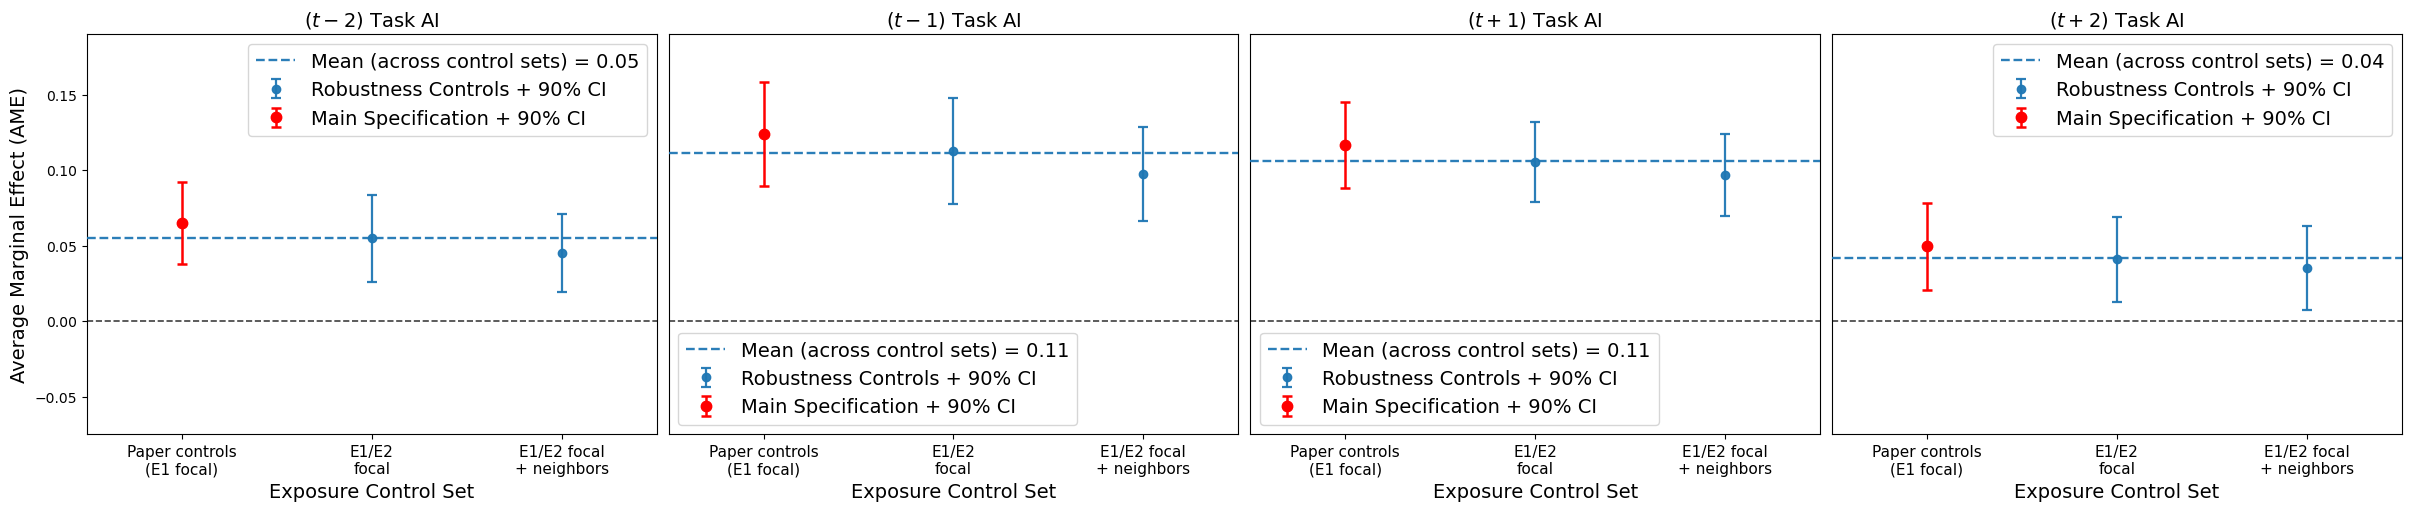

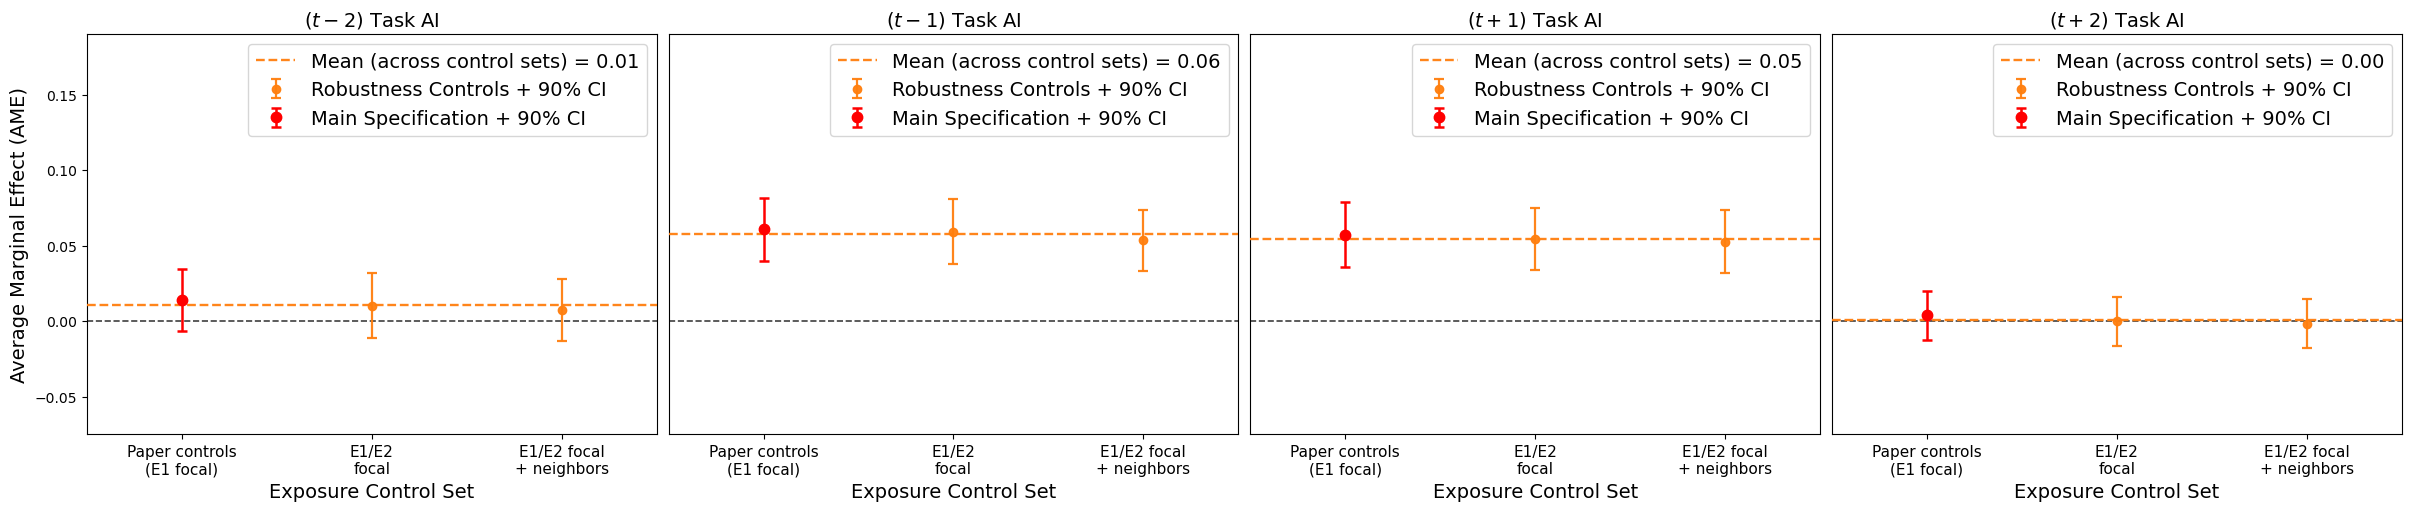

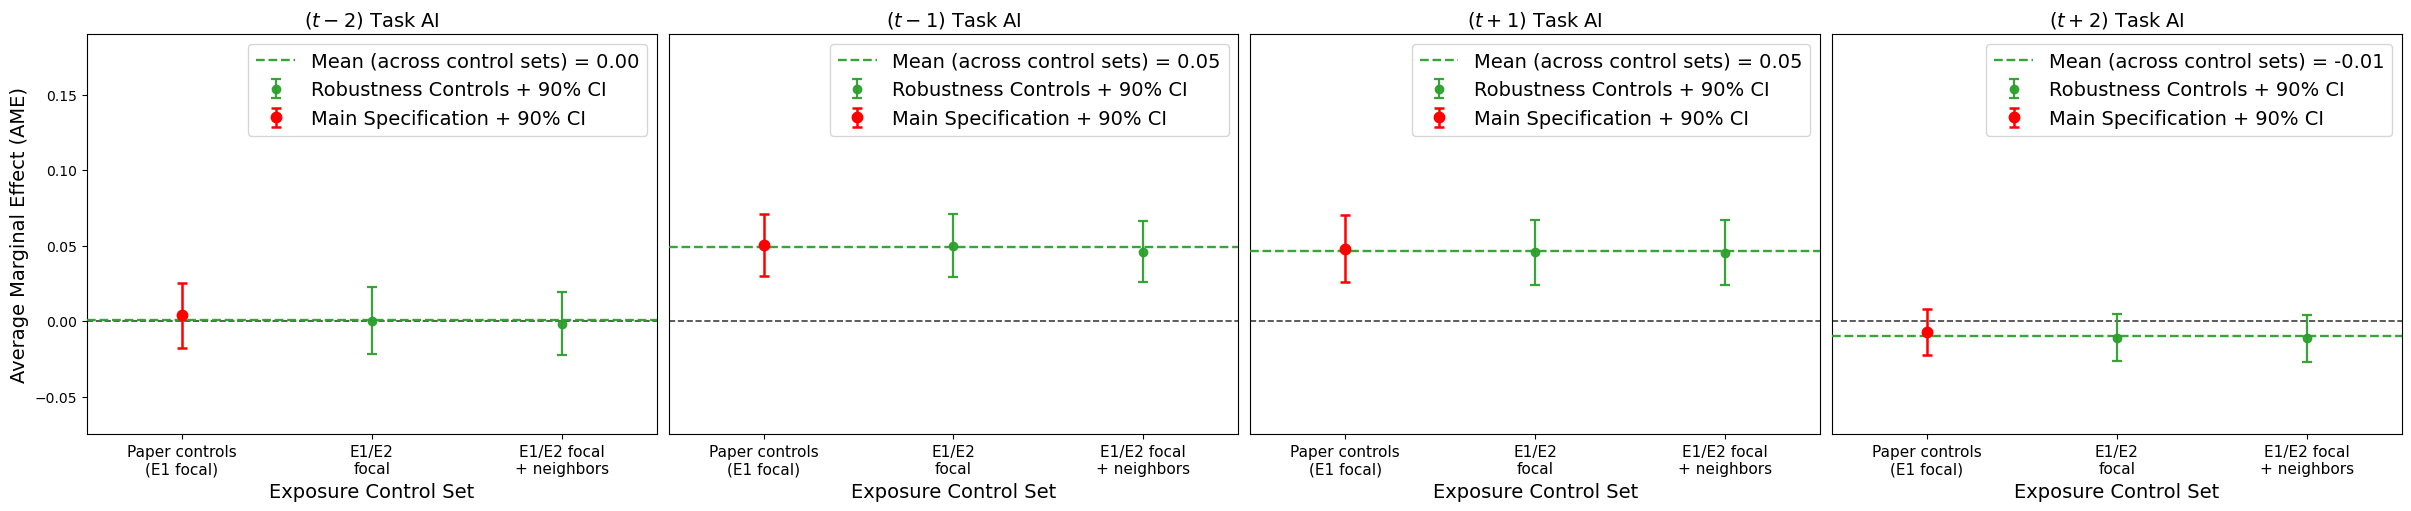

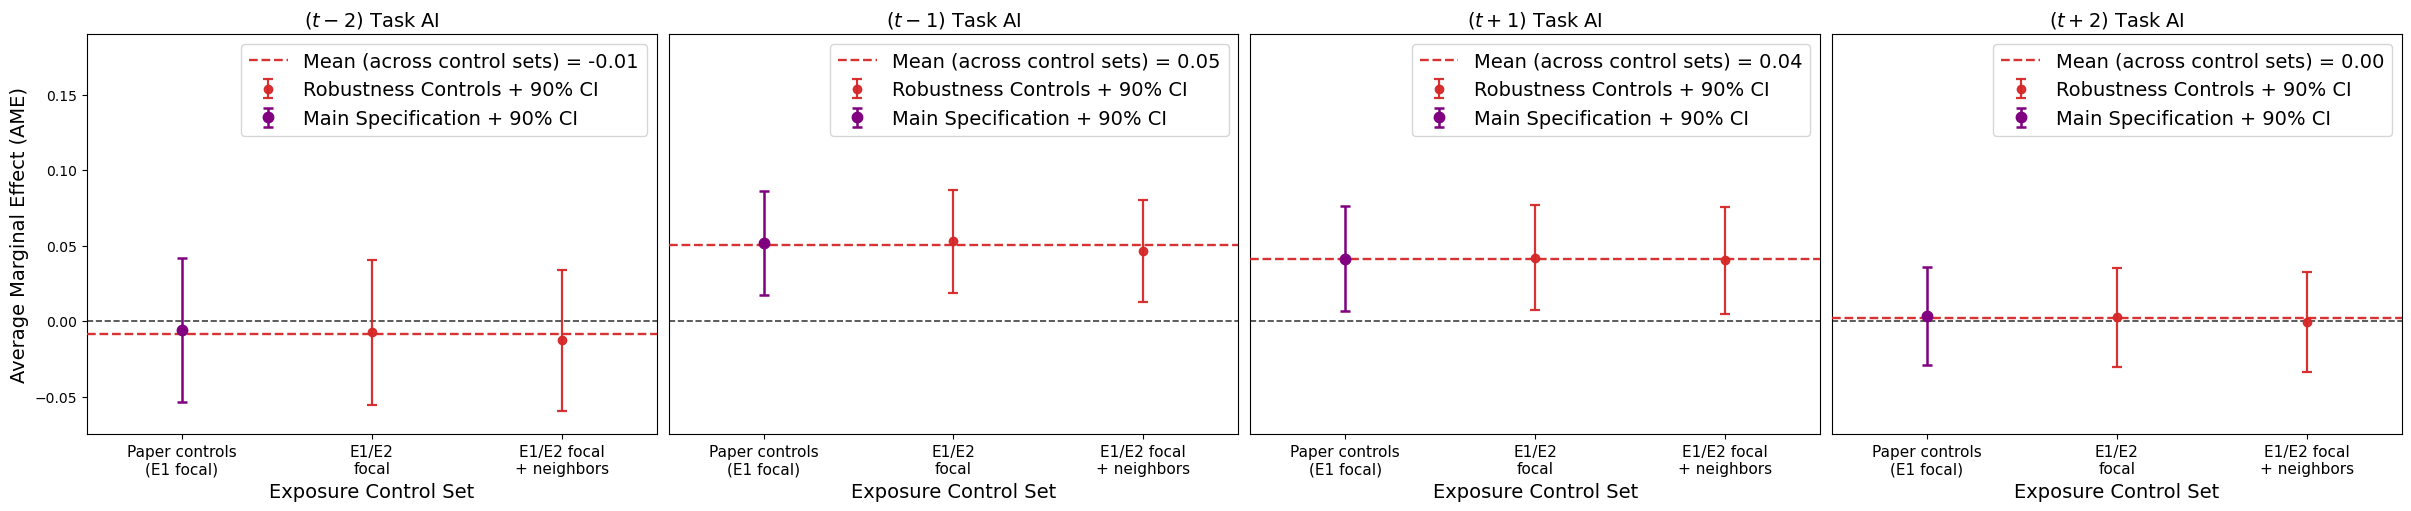

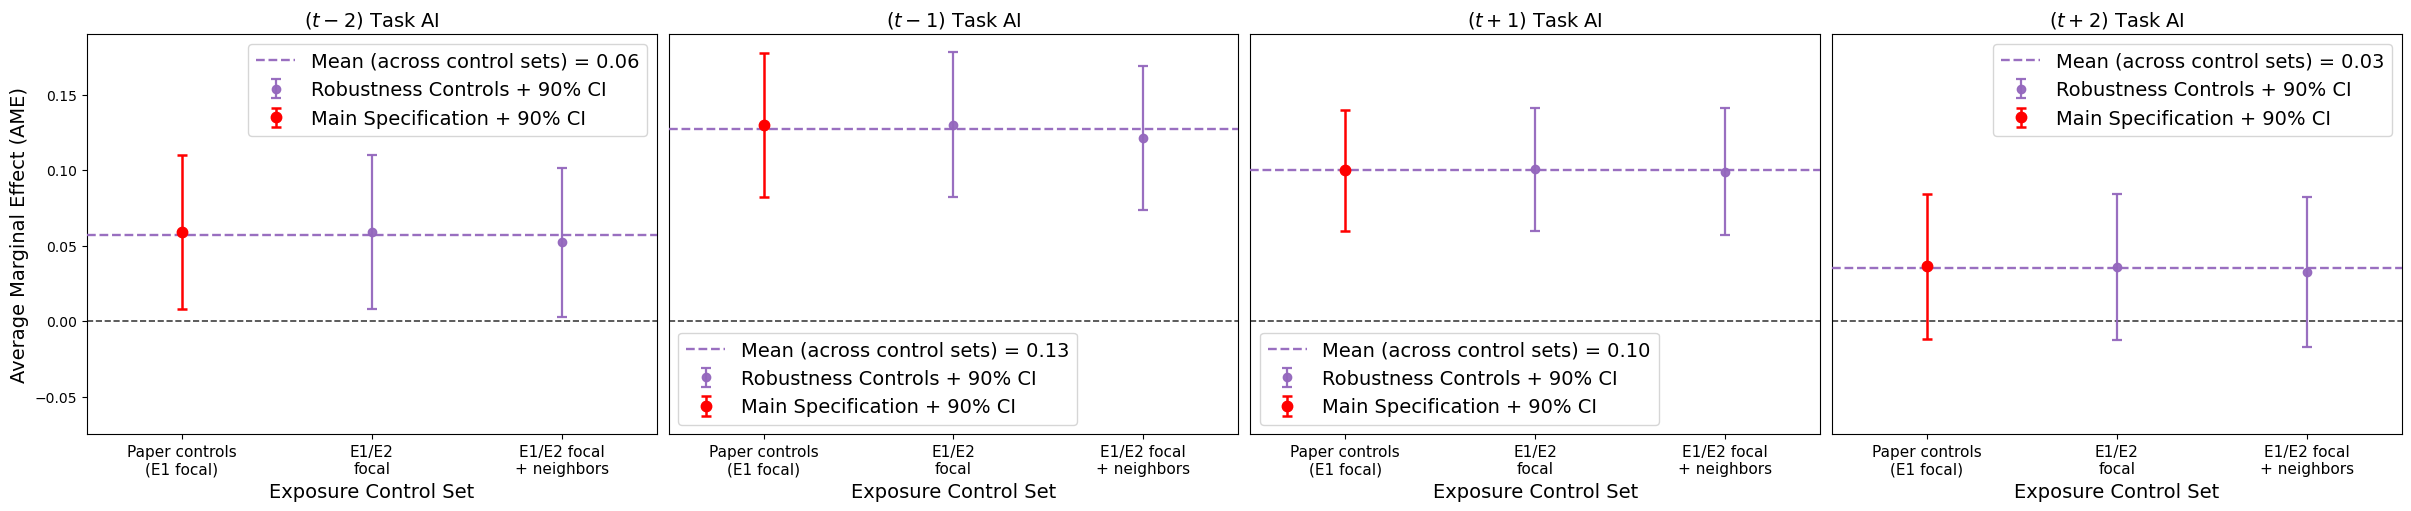

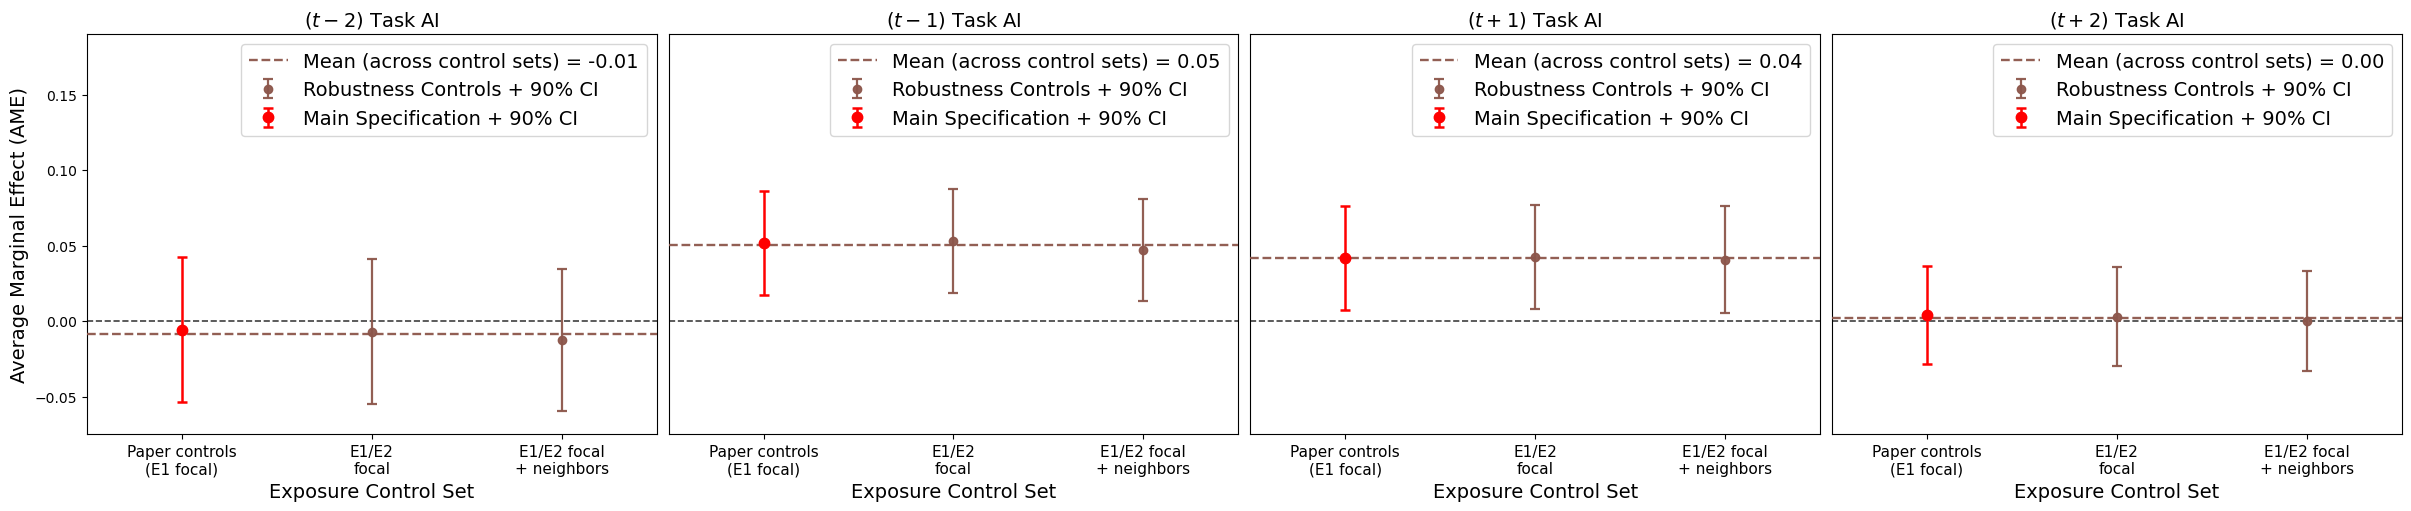

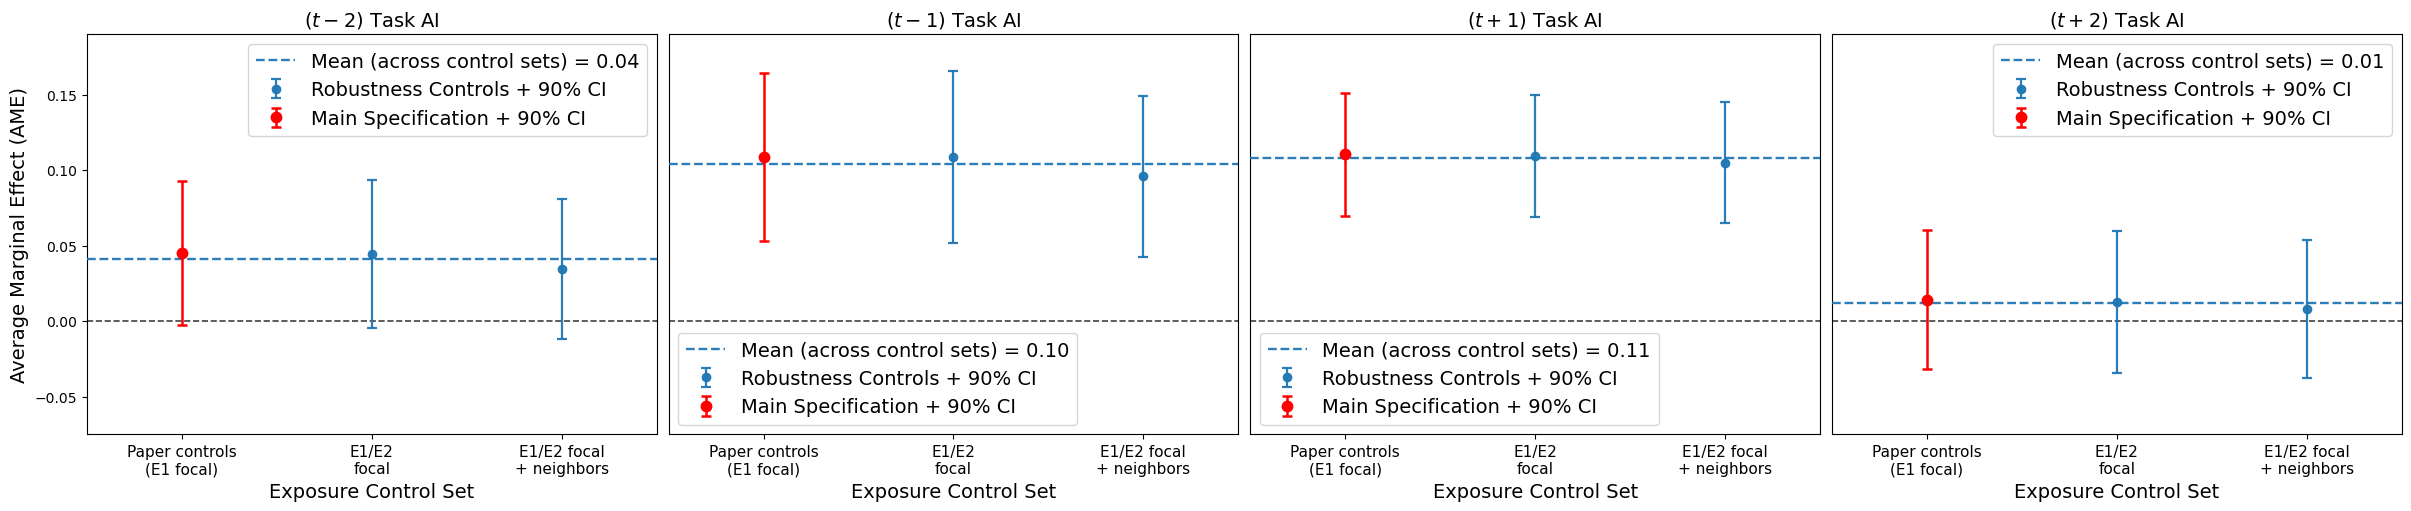

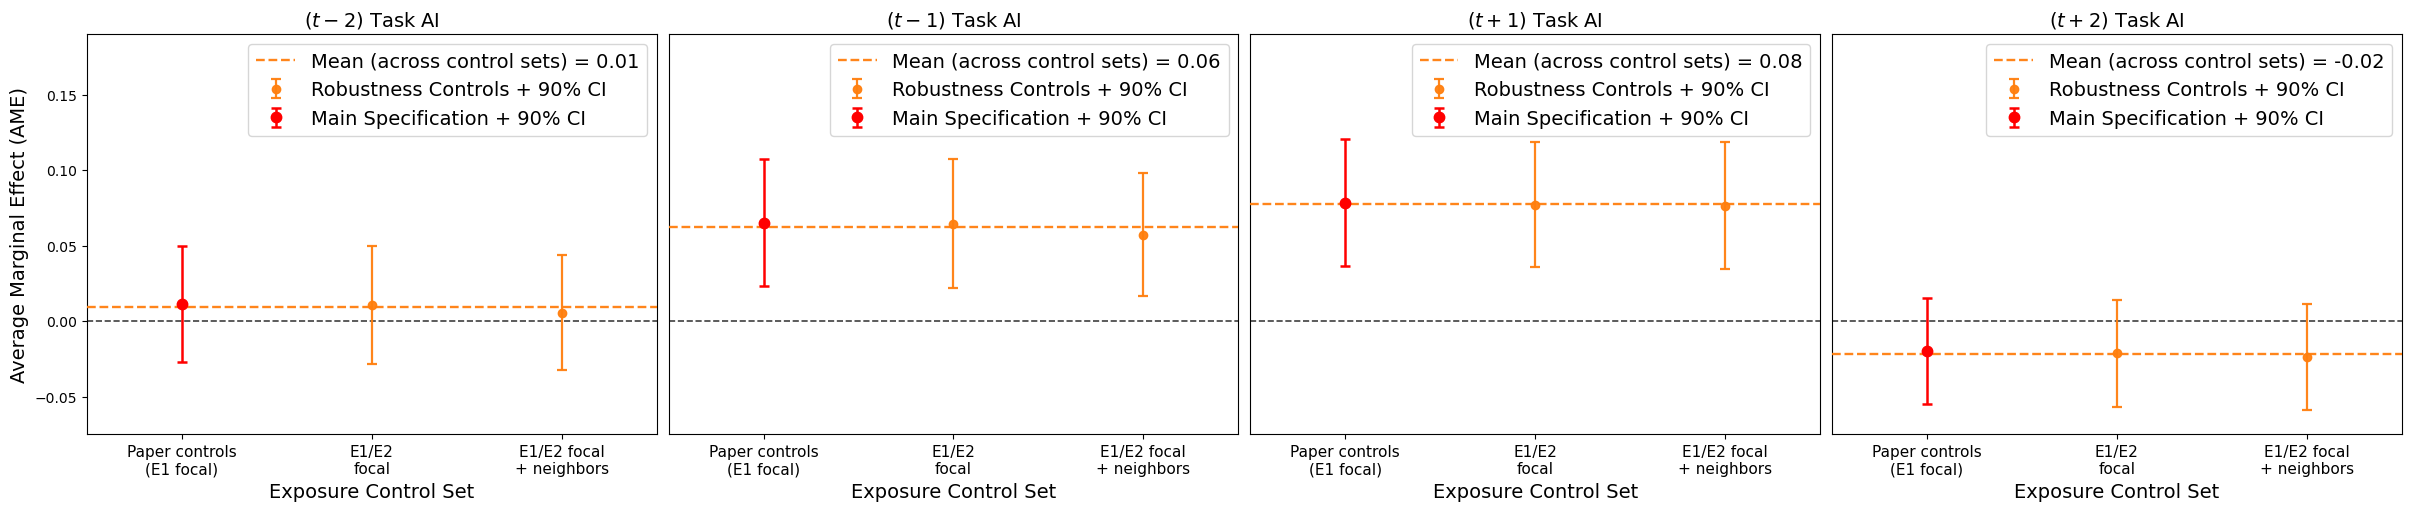

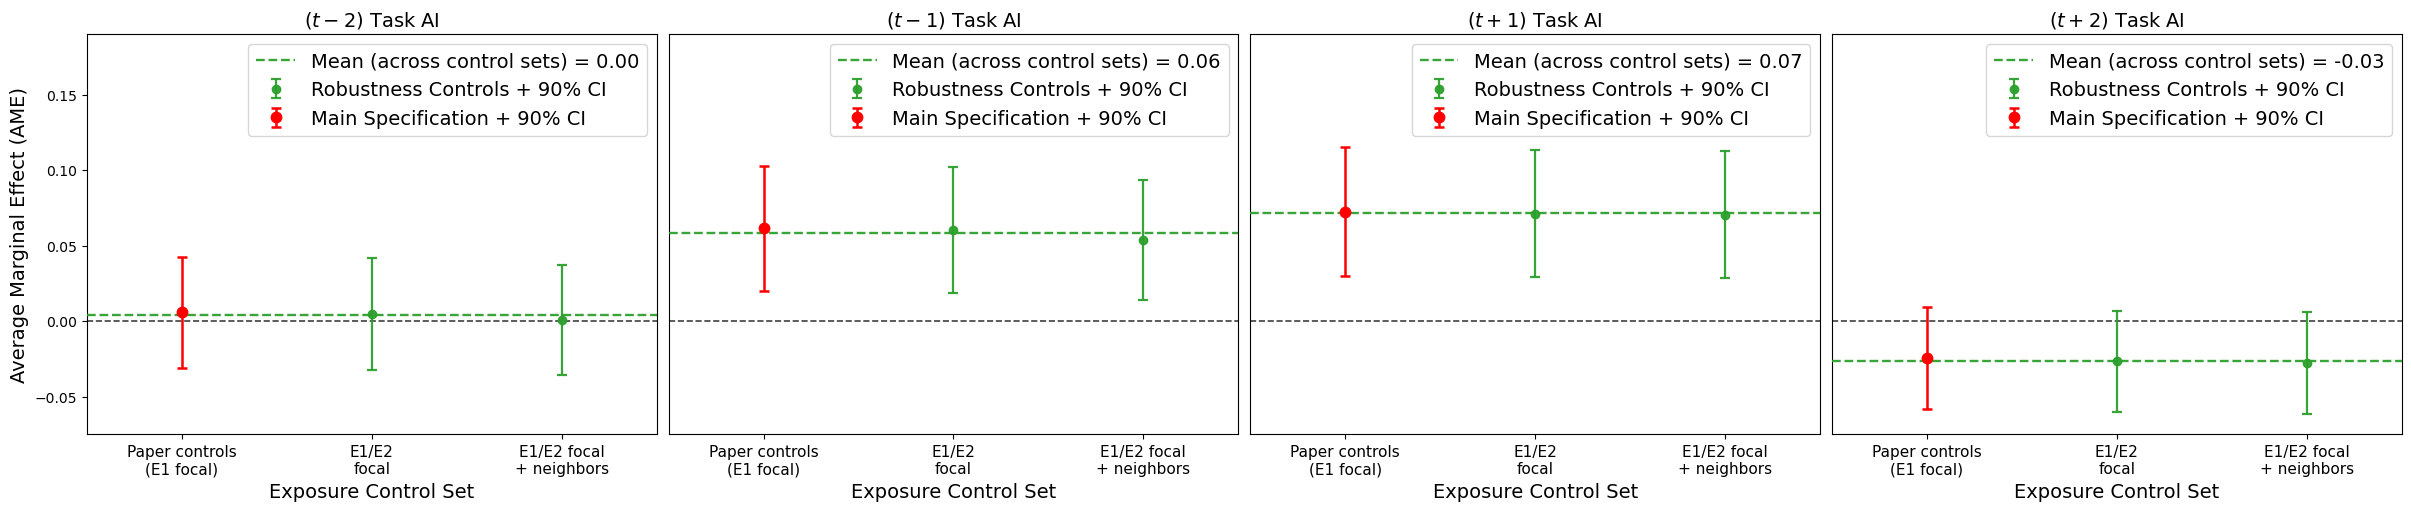

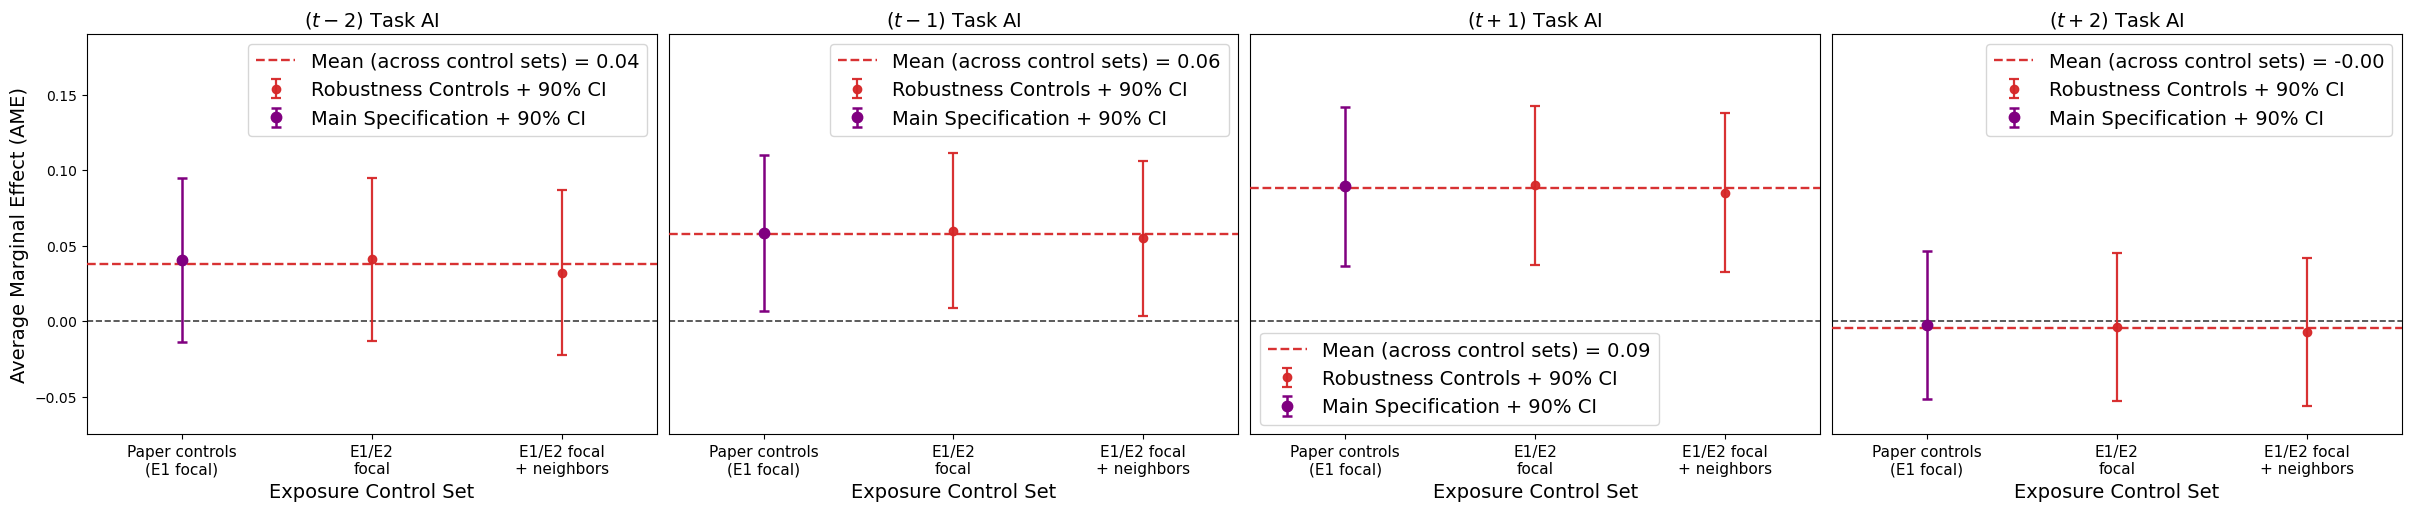

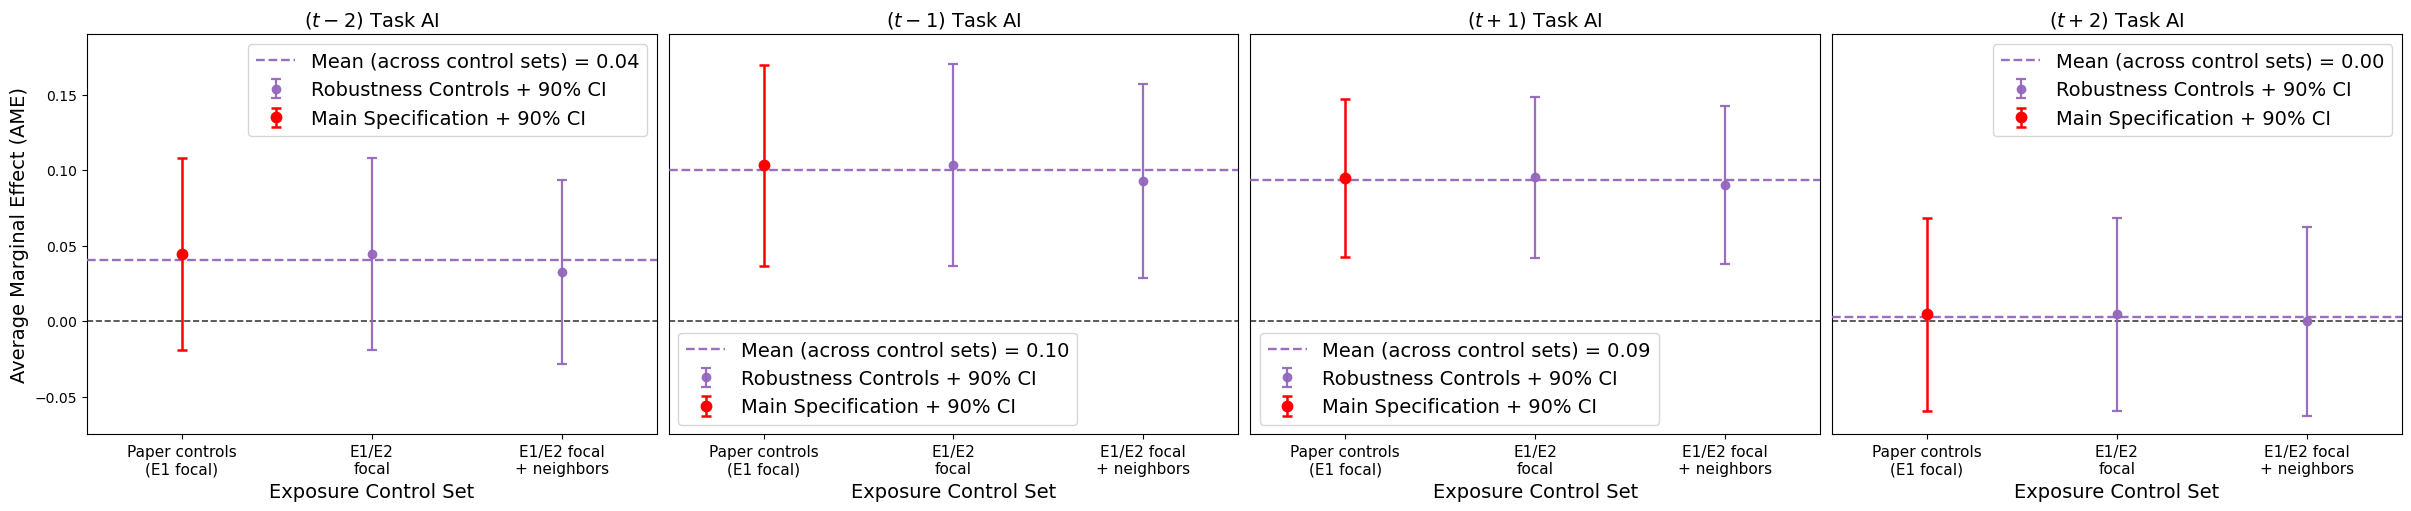

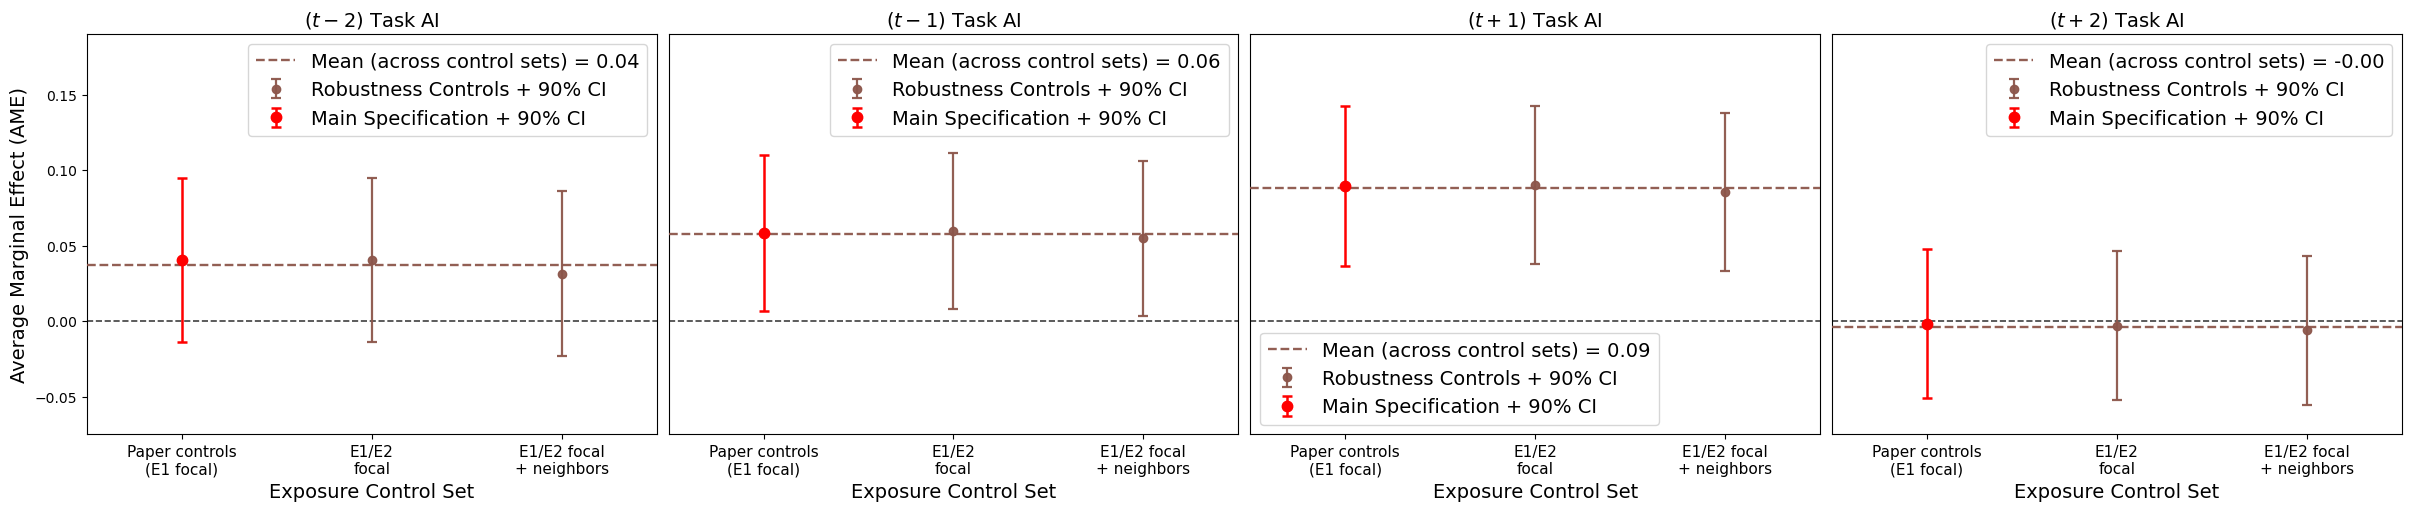

Saved 12 figures to ../writeup/plots/execTypeVaryingDWA_E1E2exposureControls


In [13]:
PLOT_TITLES = ['($t-2$) Task AI', '($t-1$) Task AI', '($t+1$) Task AI', '($t+2$) Task AI']
SPEC2COLOR = {spec: plt.cm.tab10(i % 10) for i, spec in enumerate(SPEC_ORDER)}
VARIANT_X = {'baseline': 0, 'e12_focal': 1, 'e12_focal_nbrs': 2}
X_TICKLABELS = ['Paper controls\n(E1 focal)', 'E1/E2\nfocal', 'E1/E2 focal\n+ neighbors']
Z90 = 1.645
YLIMS = (-0.075, 0.19)

def plot_sample(dataset_name, suffix):
    dfp = results[(results.dataset == dataset_name) & (results.term.isin(TARGET_REGS))].copy()
    dfp['x'] = dfp['variant'].map(VARIANT_X)
    dfp['ci_low'] = dfp['ame_coef'] - Z90 * dfp['ame_se']
    dfp['ci_high'] = dfp['ame_coef'] + Z90 * dfp['ame_se']
    for si, spec in enumerate(SPEC_ORDER):
        spec_color = SPEC2COLOR[spec]
        main_color = 'purple' if si == 3 else 'red'   # the 4th spec's series color is red
        fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)
        for j, (reg, title) in enumerate(zip(TARGET_REGS, PLOT_TITLES)):
            ax = axes[j]
            sub = dfp[(dfp['model'] == spec) & (dfp['term'] == reg)].sort_values('x')
            ax.axhline(0, color='0.25', lw=1.2, ls='--', zorder=0)
            x = sub['x'].astype(float).values; y = sub['ame_coef'].astype(float).values
            lo = sub['ci_low'].astype(float).values; hi = sub['ci_high'].astype(float).values
            yerr = np.vstack([y - lo, hi - y]); mask0 = (x == 0); m = ~mask0
            if m.any():
                ax.errorbar(x[m], y[m], yerr=yerr[:, m], fmt='o', ms=6, color=spec_color, ecolor=spec_color,
                            elinewidth=1.6, capsize=3.5, capthick=1.6, alpha=0.95, zorder=3,
                            label='Robustness Controls + 90% CI')
            if mask0.any():
                ax.errorbar(x[mask0], y[mask0], yerr=yerr[:, mask0], fmt='o', ms=7.5, color=main_color,
                            ecolor=main_color, elinewidth=1.8, capsize=3.5, capthick=1.8, alpha=1.0, zorder=6,
                            label='Main Specification + 90% CI')
            y_mean = float(np.nanmean(y))
            ax.axhline(y_mean, color=spec_color, ls='--', lw=1.7, alpha=0.95, zorder=3,
                       label=f'Mean (across control sets) = {y_mean:.2f}')
            ax.set_title(title, fontsize=14)
            ax.set_xlim(-0.5, 2.5); ax.set_xticks([0, 1, 2]); ax.set_xticklabels(X_TICKLABELS, fontsize=11)
            ax.set_xlabel('Exposure Control Set', fontsize=14)
            ax.set_ylim(*YLIMS)
            ax.legend(loc='best', fontsize=14)
            if j == 0:
                ax.set_ylabel('Average Marginal Effect (AME)', fontsize=14)
            else:
                ax.set_ylabel(''); ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        fig.savefig(f"{output_plot_path}/ame_{spec}_E1E2robustness{suffix}.png", dpi=300, bbox_inches='tight')
        plt.show()

plot_sample('full_eligible', '')
plot_sample('gpt_filtered', '_gptFiltered')
print('Saved 12 figures to', output_plot_path)